In [1]:
%load_ext autoreload
%autoreload 2
#
import warnings
warnings.filterwarnings('ignore')
#
import numpy as np
np.set_printoptions(legacy='1.25')
import pandas as pd
import os
import torch
import random
from tqdm.notebook import tqdm
import itertools
from itertools import product
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from PIL import Image, ImageDraw, ImageFont
import pytorch_lightning as pl
from torch.nn import functional as F
import pyrootutils
#
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from qwen_vl_utils import process_vision_info

In [2]:
# This notebook can be run end-to-end in a few minutes. 
# Remove the guards to replicate experiments entirely.

# UTILS

In [3]:
STENCIL_SIZE = 50
CANVAS_SIZE = [900, 900]
spritesheet = np.load('stencils.npy')
target_x = spritesheet[24]

In [4]:
#Generate non-overlapping positions for all objects
def generate_positions(n_objects,canvas_size,stencil_size) -> np.ndarray:
    # Calculate valid position range
    margin = stencil_size // 2
    min_x = margin
    max_x = canvas_size[0] - margin
    min_y = margin
    max_y = canvas_size[1] - margin
    
    # Pre-allocate positions array
    positions = np.zeros((n_objects, 2),dtype=int)
    
    # Generate valid positions
    for i in range(n_objects):
        while True:
            pos = np.random.randint([min_x, min_y], [max_x, max_y], size=2)
            if i == 0:  # First object can go anywhere
                positions[i] = pos
                break
                
            # Check distance from all previous objects
            distances = np.linalg.norm(positions[:i] - pos, axis=1)
            if np.all(distances >= stencil_size+10):#5 buffer
                positions[i] = pos
                break
    
    # Shuffle positions before returning
    np.random.shuffle(positions)
    return positions,np.linalg.norm(positions - positions[0], axis=1)

In [5]:
#place stencil on canvas
def add_stencil(canvas,stencil,color,x,y,background_color='white'):
    colored_shape = color_shape(stencil, color,background_color)  # Returns (3, H, W)
    shape_pil = Image.fromarray(colored_shape.transpose(1, 2, 0))
    if shape_pil.size != (STENCIL_SIZE, STENCIL_SIZE):
        shape_pil = shape_pil.resize((STENCIL_SIZE, STENCIL_SIZE))
    paste_x = int(x - STENCIL_SIZE // 2)
    paste_y = int(y - STENCIL_SIZE // 2)
    canvas.paste(shape_pil, (paste_x, paste_y))

In [6]:
#transform stencil color-shape
def color_shape(img: np.ndarray,stencil_color,background_color='white') -> np.ndarray:
    ''' Colors a grayscale numpy array with a red background and black shape. '''
    fg_col = np.array(mcolors.to_rgb(stencil_color)).astype(np.float32)
    bg_col = np.array(mcolors.to_rgb(background_color)).astype(np.float32)
    img = img.astype(np.float32) / 255  # Normalize grayscale
    colored = bg_col.reshape(3, 1, 1) + (fg_col.reshape(3, 1, 1) - bg_col.reshape(3, 1, 1)) * (1 - img)
    return (255 * colored).astype(np.uint8)

In [7]:
#place numbered box on canvas
def place_number_batch(canvas,xcenter,ycenter,val,num_color):
    # Define canvas size and create the image
    draw = ImageDraw.Draw(canvas)
    sq_topleft = (xcenter-STENCIL_SIZE//2, 
                       ycenter-STENCIL_SIZE//2)  # Top-left
    draw.rectangle([sq_topleft, (sq_topleft[0] + STENCIL_SIZE, 
                                      sq_topleft[1] + STENCIL_SIZE)], 
                                       fill='black')
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 
                              size=int(STENCIL_SIZE*.75))
    val = str(val)
    text_bbox = font.getbbox(val)
    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]
    text_position = (sq_topleft[0] + (STENCIL_SIZE - text_width) // 2, 
                     sq_topleft[1] + (STENCIL_SIZE - text_height) // 2)
    draw.text(text_position, val, fill=num_color, font=font)
    return canvas

In [8]:
def get_qwen():
    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct', 
                                                                torch_dtype='auto', device_map='auto')
    qwen_processor = AutoProcessor.from_pretrained('Qwen/Qwen2.5-VL-7B-Instruct') 
    qwen_vocab = qwen_processor.tokenizer.get_vocab()
    return qwen_model,qwen_processor,qwen_vocab

In [9]:
def get_qwen_inputs(model,processor,img_path,query_string):
    batch_messages = [[{'role': 'system', 'content': 'You are a helpful assistant.'}, 
      {'role': 'user', 'content': [{'type': 'image', 'image': 'file://'+img_path}, 
        {'type': 'text', 'text': query_string}]}]]    
    texts = [
            processor.apply_chat_template(
                msg,
                tokenize=False,
                add_generation_prompt=True
            ) for msg in batch_messages
        ]
    image_inputs, video_inputs = process_vision_info(batch_messages)
    inputs = processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors='pt'
        ).to(model.device)
    return inputs

In [10]:
def ask_qwen_numbers(model,processor,vocab,img_path,query):
    inputs = get_qwen_inputs(model,processor,img_path,query)
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=128,
                return_dict_in_generate=True, output_scores=True)
    num_system_tokens = 14
    num_image_tokens = 326  # 18 x 18 + 2 (start, end image token)
    num_user_tokens = inputs.input_ids.shape[1] - num_system_tokens - num_image_tokens
    str_out = processor.decode(output.sequences[0][num_system_tokens+num_image_tokens+num_user_tokens:-1])
    dig_1 = [output['scores'][0][0].cpu().numpy()[vocab[str(x)]] for x in range(10)]
    dig_2 = [output['scores'][1][0].cpu().numpy()[vocab[str(x)]] for x in range(10)]
    str_out = str_out.replace('.','').strip()
    try:
        assert 10 <= int(str_out) < 100
    except:
        print('UNEXPECTED ANSWER --------->'+str_out)
    return {'Q':query,'A':str_out,'d1':dig_1,'d2':dig_2}

In [11]:
def get_gemma():
    model_id = "google/gemma-3-12b-it"    
    gemma_model = Gemma3ForConditionalGeneration.from_pretrained(
        model_id, device_map="auto"
    ).eval()    
    gemma_processor = AutoProcessor.from_pretrained(model_id)
    gemma_vocab = gemma_processor.tokenizer.get_vocab()
    return gemma_model,gemma_processor,gemma_vocab

In [12]:
def get_gemma_inputs(model,processor,img_path,query_string):
    messages = [{"role": "system","content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user","content": [{"type": "image", "image": img_path},{"type": "text", "text": query_string}]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device, dtype=torch.bfloat16)
    return inputs

In [13]:
def ask_gemma_numbers(some_model,some_vocab,some_processor,img_path,query):
    inputs = get_gemma_inputs(some_model,some_processor,img_path,query)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        output = some_model.generate(**inputs, max_new_tokens=100, do_sample=False,
                return_dict_in_generate=True, output_scores=True)
    str_out = some_processor.decode(output['sequences'][0][input_len:-1])
    dig_1 = [output['scores'][0][0].cpu().numpy()[some_vocab[str(x)]] for x in range(10)]
    dig_2 = [output['scores'][1][0].cpu().numpy()[some_vocab[str(x)]] for x in range(10)]
    str_out = str_out.replace('.','').strip()
    try:
        assert 10 <= int(str_out) < 100
    except:
        print('UNEXPECTED ANSWER --------->'+str_out)
    return {'Q':query,'A':str_out,'d1':dig_1,'d2':dig_2}

# SIMILARITY

## Dataset

In [14]:
NUMBER_SIMILARITY_DATASET = 'number_similarity_dataset/'
os.makedirs(NUMBER_SIMILARITY_DATASET, exist_ok=True)

In [15]:
# Creates a dataframe with the description/metadata of images

columns = ['ID','num_distractors','target_X','target_Y'] + [f'D{str(i).zfill(2)}_{attr}' \
                                        for i in range(10,100) for attr in ['X', 'Y', 'DIST']]
metadata_similarity = pd.DataFrame(columns=columns)
#
for num_distractors in range(2,91):
    for run in range(12):
        #The first element is the target
        positions,distances = generate_positions(num_distractors+1,CANVAS_SIZE,STENCIL_SIZE)
        values = np.random.choice(range(10,100),size=num_distractors,replace=False)
        #marshall row
        row = {'ID':str(len(metadata_similarity)).zfill(4),'num_distractors':num_distractors,
                                           'target_X':positions[0,0],'target_Y':positions[0,1]}
        for ((x,y),v,d) in zip(positions[1:],values,distances[1:]): 
            num_id = str(v).zfill(2)
            row.update({'D'+num_id+'_X':x,'D'+num_id+'_Y':y,'D'+num_id+'_DIST':d})
        metadata_similarity = pd.concat([metadata_similarity, pd.DataFrame([row])], ignore_index=True)

In [16]:
print(metadata_similarity.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  627
target_Y                  225
D12_X                     388
D12_Y                     302
D12_DIST           251.097591
D76_X                     706
D76_Y                     280
D76_DIST            96.260064
Name: 0, dtype: object


In [17]:
#metatada to image
def make_image_num_sim(instructions):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    add_stencil(canvas,target_x,'red',instructions['target_X'],instructions['target_Y'])
    numbers = [col.split('_')[0][1:] for col in instructions.filter(like='_DIST').dropna().keys()]
    for n in numbers:
        canvas = place_number_batch(canvas,instructions['D'+n+'_X'],instructions['D'+n+'_Y'],n,'white')
    return canvas

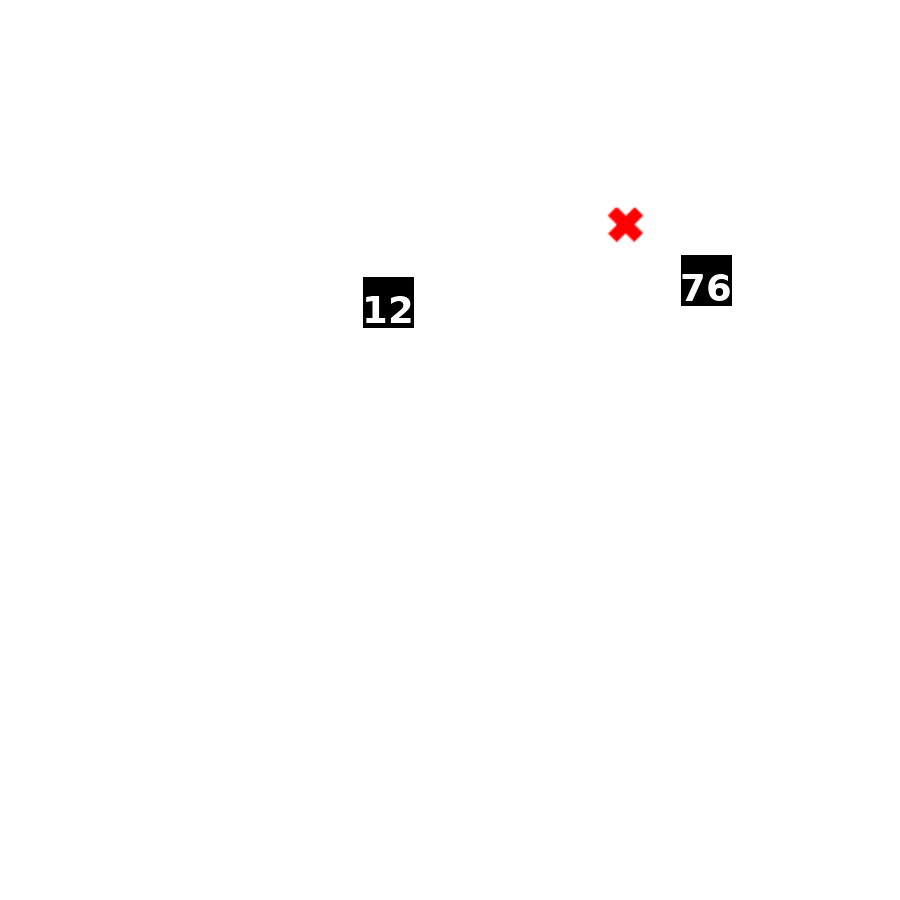

In [18]:
make_image_num_sim(metadata_similarity.iloc[0])

In [19]:
#transform each metadata row into one image
for i in range(metadata_similarity.shape[0]):
    instructions = metadata_similarity.iloc[i]
    canvas = make_image_num_sim(instructions)
    canvas.save(NUMBER_SIMILARITY_DATASET+instructions['ID']+'.png')

## QWEN

In [26]:
qwen_model,qwen_processor,qwen_vocab = get_qwen()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [27]:
qwen_num_sim = metadata_similarity.copy()
qwen_num_sim['answer']=None
for d in range(10):
    qwen_num_sim['1st_digit_'+str(d)]=None
for d in range(10):
    qwen_num_sim['2nd_digit_'+str(d)]=None

In [28]:
query = "The picture contains several black squares with white numbers. "+\
            "There is also a red X. Which black square is the closest to the X? Respond with only the square's number.\n"

for i, row in qwen_num_sim.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = NUMBER_SIMILARITY_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_qwen_numbers(qwen_model,qwen_processor,qwen_vocab,img_path,query)
    qwen_num_sim.loc[i,'answer']=response['A']
    for d in range(10):
        qwen_num_sim.loc[i,'1st_digit_'+str(d)]=response['d1'][d]
        qwen_num_sim.loc[i,'2nd_digit_'+str(d)]=response['d2'][d]

In [29]:
qwen_num_sim

,ID,num_distractors,target_X,target_Y,D10_X,D10_Y,D10_DIST,D11_X,D11_Y,D11_DIST,...,2nd_digit_0,2nd_digit_1,2nd_digit_2,2nd_digit_3,2nd_digit_4,2nd_digit_5,2nd_digit_6,2nd_digit_7,2nd_digit_8,2nd_digit_9
0,0000,2,627,225,NaN,NaN,NaN,NaN,NaN,NaN,...,19000000.0,18625000.0,19125000.0,17750000.0,19000000.0,20500000.0,32500000.0,18571430.0,20375000.0,18875000.0
1,0001,2,115,149,NaN,NaN,NaN,NaN,NaN,NaN,...,17875000.0,17142858.0,17125000.0,14437500.0,15562500.0,15562500.0,18000000.0,16250000.0,17500000.0,29750000.0
2,0002,2,68,130,NaN,NaN,NaN,NaN,NaN,NaN,...,20000000.0,19125000.0,17261906.0,17750000.0,17625000.0,17375000.0,18875000.0,20500000.0,31625000.0,20125000.0
3,0003,2,97,225,NaN,NaN,NaN,NaN,NaN,NaN,...,21125000.0,34000000.0,20375000.0,19250000.0,19625000.0,18809524.0,20000000.0,20375000.0,19750000.0,22375000.0
4,0004,2,595,103,NaN,NaN,NaN,NaN,NaN,NaN,...,16375000.0,15375000.0,15476192.0,15062500.0,28000000.0,18375000.0,16875000.0,15437500.0,16125000.0,26625000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1063,90,215,171,294,463,302.497934,231,407,236.541751,...,None,None,None,None,None,None,None,None,None,None
1064,1064,90,395,136,698,337,363.606931,634,332,309.090602,...,None,None,None,None,None,None,None,None,None,None
1065,1065,90,30,478,489,276,501.482801,441,658,448.688088,...,None,None,None,None,None,None,None,None,None,None
1066,1066,90,145,365,279,288,154.547727,447,613,390.778710,...,None,None,None,None,None,None,None,None,None,None


In [30]:
print(qwen_num_sim.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  627
target_Y                  225
D12_X                     388
D12_Y                     302
D12_DIST           251.097591
D76_X                     706
D76_Y                     280
D76_DIST            96.260064
answer                     76
1st_digit_0        20250000.0
1st_digit_1        28125000.0
1st_digit_2        25375000.0
1st_digit_3        19375000.0
1st_digit_4        22500000.0
1st_digit_5        21125000.0
1st_digit_6        25875000.0
1st_digit_7        31750000.0
1st_digit_8        20875000.0
1st_digit_9        19875000.0
2nd_digit_0        19000000.0
2nd_digit_1        18625000.0
2nd_digit_2        19125000.0
2nd_digit_3        17750000.0
2nd_digit_4        19000000.0
2nd_digit_5        20500000.0
2nd_digit_6        32500000.0
2nd_digit_7        18571430.0
2nd_digit_8        20375000.0
2nd_digit_9        18875000.0
Name: 0, dtype: object


## Gemma

In [35]:
gemma_model,gemma_processor,gemma_vocab = get_gemma()

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [36]:
gemma_num_sim = metadata_similarity.copy()
gemma_num_sim['answer']=None
for d in range(10):
    gemma_num_sim['1st_digit_'+str(d)]=None
for d in range(10):
    gemma_num_sim['2nd_digit_'+str(d)]=None

In [37]:
query = "The picture contains several black squares with white numbers. "+\
            "There is also a red X. Which black square is the closest to the X? Respond with only the square's number.\n"

for i, row in gemma_num_sim.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = NUMBER_SIMILARITY_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_gemma_numbers(gemma_model,gemma_vocab,gemma_processor,img_path,query)
    gemma_num_sim.loc[i,'answer']=response['A']
    for d in range(10):
        gemma_num_sim.loc[i,'1st_digit_'+str(d)]=response['d1'][d]
        gemma_num_sim.loc[i,'2nd_digit_'+str(d)]=response['d2'][d]

In [38]:
gemma_num_sim

,ID,num_distractors,target_X,target_Y,D10_X,D10_Y,D10_DIST,D11_X,D11_Y,D11_DIST,...,2nd_digit_0,2nd_digit_1,2nd_digit_2,2nd_digit_3,2nd_digit_4,2nd_digit_5,2nd_digit_6,2nd_digit_7,2nd_digit_8,2nd_digit_9
0,0000,2,627,225,NaN,NaN,NaN,NaN,NaN,NaN,...,16.25,14.3125,16.75,15.8125,14.6875,15.625,33.75,15.3125,17.0,13.5625
1,0001,2,115,149,NaN,NaN,NaN,NaN,NaN,NaN,...,14.0,13.6875,15.0,12.875,12.5625,14.25,15.9375,13.25,12.625,33.0
2,0002,2,68,130,NaN,NaN,NaN,NaN,NaN,NaN,...,18.125,14.75,18.25,20.0,13.875,16.875,21.25,14.3125,35.0,18.625
3,0003,2,97,225,NaN,NaN,NaN,NaN,NaN,NaN,...,16.375,34.25,17.375,15.875,15.1875,15.375,14.9375,15.25,17.25,16.75
4,0004,2,595,103,NaN,NaN,NaN,NaN,NaN,NaN,...,14.5625,14.5625,16.875,15.375,31.875,15.1875,15.625,15.6875,15.4375,23.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1063,90,215,171,294,463,302.497934,231,407,236.541751,...,None,None,None,None,None,None,None,None,None,None
1064,1064,90,395,136,698,337,363.606931,634,332,309.090602,...,None,None,None,None,None,None,None,None,None,None
1065,1065,90,30,478,489,276,501.482801,441,658,448.688088,...,None,None,None,None,None,None,None,None,None,None
1066,1066,90,145,365,279,288,154.547727,447,613,390.778710,...,None,None,None,None,None,None,None,None,None,None


In [39]:
print(gemma_num_sim.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  627
target_Y                  225
D12_X                     388
D12_Y                     302
D12_DIST           251.097591
D76_X                     706
D76_Y                     280
D76_DIST            96.260064
answer                     76
1st_digit_0           13.8125
1st_digit_1            25.375
1st_digit_2             16.75
1st_digit_3             16.75
1st_digit_4            15.375
1st_digit_5             16.75
1st_digit_6            18.125
1st_digit_7              32.0
1st_digit_8           15.8125
1st_digit_9           15.9375
2nd_digit_0             16.25
2nd_digit_1           14.3125
2nd_digit_2             16.75
2nd_digit_3           15.8125
2nd_digit_4           14.6875
2nd_digit_5            15.625
2nd_digit_6             33.75
2nd_digit_7           15.3125
2nd_digit_8              17.0
2nd_digit_9           13.5625
Name: 0, dtype: object


# IDENTIFICATION

## Dataset

In [20]:
NUMBER_IDENTIFICATION_DATASET = 'number_identification_dataset/'
os.makedirs(NUMBER_IDENTIFICATION_DATASET, exist_ok=True)

In [21]:
# Creates a dataframe with the description/metadata of images

columns = ['ID','num_distractors','target_X','target_Y','target_num'] + [f'D{str(i).zfill(2)}_{attr}' \
                                        for i in range(10,100) for attr in ['X', 'Y', 'DIST']]
metadata_identification = pd.DataFrame(columns=columns)
#
for num_distractors in range(2,91):
    for run in range(12):
        #FIRST ELEM IS THE RED ONE
        positions,distances = generate_positions(num_distractors,CANVAS_SIZE,STENCIL_SIZE)
        values = np.random.choice(range(10,100),size=num_distractors,replace=False)
        #marshall row
        row = {'ID':str(len(metadata_identification)).zfill(4),'num_distractors':num_distractors,
                        'target_X':positions[0,0],'target_Y':positions[0,1],'target_num':values[0]}
        for ((x,y),v,d) in zip(positions,values,distances): 
            num_id = str(v).zfill(2)
            row.update({'D'+num_id+'_X':x,'D'+num_id+'_Y':y,'D'+num_id+'_DIST':d})
        metadata_identification = pd.concat([metadata_identification, pd.DataFrame([row])], ignore_index=True)

In [22]:
print(metadata_identification.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  350
target_Y                  524
target_num                 69
D40_X                     316
D40_Y                     190
D40_DIST           335.726079
D69_X                     350
D69_Y                     524
D69_DIST                  0.0
Name: 0, dtype: object


In [23]:
def make_image_num_iden(instructions):
    canvas = Image.new('RGB', CANVAS_SIZE, 'white')
    numbers = [col.split('_')[0][1:] for col in instructions.filter(like='_DIST').dropna().keys()]
    for n in numbers:
        col = 'red' if str(n) == str(instructions['target_num']) else 'white'
        canvas = place_number_batch(canvas,instructions['D'+n+'_X'],instructions['D'+n+'_Y'],n,col)
    return canvas

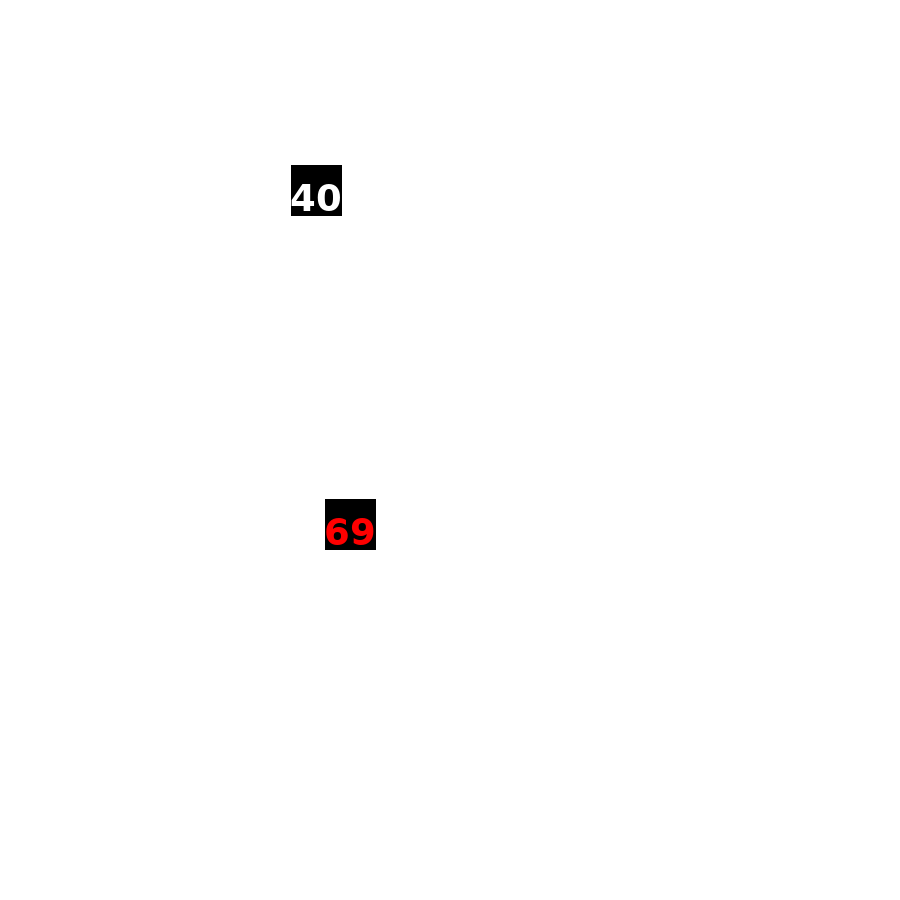

In [24]:
make_image_num_iden(metadata_identification.iloc[0])

In [25]:
#transform each metadata row into one image
for i in range(metadata_identification.shape[0]):
    instructions = metadata_identification.iloc[i]
    canvas = make_image_num_iden(instructions)
    canvas.save(NUMBER_IDENTIFICATION_DATASET+instructions['ID']+'.png')

## QWEN

In [ ]:
qwen_model,qwen_processor,qwen_vocab = get_qwen()

In [31]:
qwen_num_iden = metadata_identification.copy()
qwen_num_iden['answer']=None
for d in range(10):
    qwen_num_iden['1st_digit_'+str(d)]=None
for d in range(10):
    qwen_num_iden['2nd_digit_'+str(d)]=None

In [32]:
query = "The picture contains several black squares with white numbers. "+\
            "There is also a black square with a number in red. Which one is it? Respond with only the square's number.\n"

for i, row in qwen_num_iden.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = NUMBER_IDENTIFICATION_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_qwen_numbers(qwen_model,qwen_processor,qwen_vocab,img_path,query)
    qwen_num_iden.loc[i,'answer']=response['A']
    for d in range(10):
        qwen_num_iden.loc[i,'1st_digit_'+str(d)]=response['d1'][d]
        qwen_num_iden.loc[i,'2nd_digit_'+str(d)]=response['d2'][d]

In [33]:
qwen_num_iden

,ID,num_distractors,target_X,target_Y,target_num,D10_X,D10_Y,D10_DIST,D11_X,D11_Y,...,2nd_digit_0,2nd_digit_1,2nd_digit_2,2nd_digit_3,2nd_digit_4,2nd_digit_5,2nd_digit_6,2nd_digit_7,2nd_digit_8,2nd_digit_9
0,0000,2,350,524,69,NaN,NaN,NaN,NaN,NaN,...,20250000.0,17875000.0,17625000.0,18625000.0,18750000.0,18875000.0,18809524.0,19625000.0,20125000.0,33250000.0
1,0001,2,471,339,88,NaN,NaN,NaN,NaN,NaN,...,19375000.0,15500000.0,16500000.0,16125000.0,15812500.0,17000000.0,19125000.0,19000000.0,30357146.0,20375000.0
2,0002,2,554,673,49,NaN,NaN,NaN,NaN,NaN,...,18375000.0,18000000.0,20000000.0,17000000.0,17500002.0,17875000.0,17875000.0,19875000.0,19500000.0,33000000.0
3,0003,2,546,577,70,NaN,NaN,NaN,NaN,NaN,...,31250000.0,18125000.0,17875000.0,16750000.0,17375000.0,17250000.0,18125000.0,18809524.0,18375000.0,20375000.0
4,0004,2,135,858,83,NaN,NaN,NaN,NaN,NaN,...,19125000.0,19125000.0,20000000.0,32250000.0,19125000.0,18750000.0,18250000.0,18375000.0,19166668.0,19000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1063,90,647,807,20,41,284,800.477982,141,432,...,None,None,None,None,None,None,None,None,None,None
1064,1064,90,235,207,52,440,821,647.318314,794,134,...,None,None,None,None,None,None,None,None,None,None
1065,1065,90,351,182,56,315,726,545.189875,428,403,...,None,None,None,None,None,None,None,None,None,None
1066,1066,90,135,467,20,590,35,627.414536,628,804,...,None,None,None,None,None,None,None,None,None,None


In [34]:
print(qwen_num_iden.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  350
target_Y                  524
target_num                 69
D40_X                     316
D40_Y                     190
D40_DIST           335.726079
D69_X                     350
D69_Y                     524
D69_DIST                  0.0
answer                     69
1st_digit_0        18250000.0
1st_digit_1        19750000.0
1st_digit_2        19875000.0
1st_digit_3        22625000.0
1st_digit_4        20625000.0
1st_digit_5        19250000.0
1st_digit_6        31125000.0
1st_digit_7        19875000.0
1st_digit_8        19000000.0
1st_digit_9        18875000.0
2nd_digit_0        20250000.0
2nd_digit_1        17875000.0
2nd_digit_2        17625000.0
2nd_digit_3        18625000.0
2nd_digit_4        18750000.0
2nd_digit_5        18875000.0
2nd_digit_6        18809524.0
2nd_digit_7        19625000.0
2nd_digit_8        20125000.0
2nd_digit_9        33250000.0
Name: 0, dtype: object


## Gemma

In [ ]:
gemma_model,gemma_processor,gemma_vocab = get_gemma()

In [40]:
gemma_num_iden = metadata_similarity.copy()
gemma_num_iden['answer']=None
for d in range(10):
    gemma_num_iden['1st_digit_'+str(d)]=None
for d in range(10):
    gemma_num_iden['2nd_digit_'+str(d)]=None

In [41]:
query = "The picture contains several black squares with white numbers. "+\
            "There is also a black square with a number in red. Which one is it? Respond with only the square's number.\n"

for i, row in gemma_num_iden.iterrows():
    if i==5:#GUARD
        break#remove this guard to run over all images
    img_path = NUMBER_IDENTIFICATION_DATASET+(str(int(row['ID'])).zfill(4))+'.png'
    response = ask_gemma_numbers(gemma_model,gemma_vocab,gemma_processor,img_path,query)
    gemma_num_iden.loc[i,'answer']=response['A']
    for d in range(10):
        gemma_num_iden.loc[i,'1st_digit_'+str(d)]=response['d1'][d]
        gemma_num_iden.loc[i,'2nd_digit_'+str(d)]=response['d2'][d]

In [42]:
gemma_num_iden

,ID,num_distractors,target_X,target_Y,D10_X,D10_Y,D10_DIST,D11_X,D11_Y,D11_DIST,...,2nd_digit_0,2nd_digit_1,2nd_digit_2,2nd_digit_3,2nd_digit_4,2nd_digit_5,2nd_digit_6,2nd_digit_7,2nd_digit_8,2nd_digit_9
0,0000,2,627,225,NaN,NaN,NaN,NaN,NaN,NaN,...,16.75,14.3125,15.625,15.375,14.125,14.75,18.5,13.875,16.25,35.5
1,0001,2,115,149,NaN,NaN,NaN,NaN,NaN,NaN,...,15.5625,12.5625,13.125,14.0,11.875,12.125,16.125,12.8125,32.5,15.25
2,0002,2,68,130,NaN,NaN,NaN,NaN,NaN,NaN,...,16.875,16.5,17.5,17.125,14.8125,16.0,17.75,15.3125,16.375,36.0
3,0003,2,97,225,NaN,NaN,NaN,NaN,NaN,NaN,...,33.5,15.625,15.625,15.375,13.6875,13.1875,14.4375,13.375,15.625,16.875
4,0004,2,595,103,NaN,NaN,NaN,NaN,NaN,NaN,...,15.75,16.75,18.625,36.25,15.9375,16.375,17.375,15.25,17.625,15.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1063,90,215,171,294,463,302.497934,231,407,236.541751,...,None,None,None,None,None,None,None,None,None,None
1064,1064,90,395,136,698,337,363.606931,634,332,309.090602,...,None,None,None,None,None,None,None,None,None,None
1065,1065,90,30,478,489,276,501.482801,441,658,448.688088,...,None,None,None,None,None,None,None,None,None,None
1066,1066,90,145,365,279,288,154.547727,447,613,390.778710,...,None,None,None,None,None,None,None,None,None,None


In [43]:
print(gemma_num_iden.iloc[0].dropna())

ID                       0000
num_distractors             2
target_X                  627
target_Y                  225
D12_X                     388
D12_Y                     302
D12_DIST           251.097591
D76_X                     706
D76_Y                     280
D76_DIST            96.260064
answer                     69
1st_digit_0            14.375
1st_digit_1           13.9375
1st_digit_2           14.8125
1st_digit_3           14.8125
1st_digit_4            16.625
1st_digit_5           14.4375
1st_digit_6            31.375
1st_digit_7              14.0
1st_digit_8              13.5
1st_digit_9              15.5
2nd_digit_0             16.75
2nd_digit_1           14.3125
2nd_digit_2            15.625
2nd_digit_3            15.375
2nd_digit_4            14.125
2nd_digit_5             14.75
2nd_digit_6              18.5
2nd_digit_7            13.875
2nd_digit_8             16.25
2nd_digit_9              35.5
Name: 0, dtype: object
